# Single-Pulsar Marginalization with JaxPINT

This notebook demonstrates the analytic timing-model marginalization machinery
in `jaxpint.bayes.marginal`. We use PSR NGC6440E (PINT bundled example) so the
data path matches the other single-pulsar notebooks.

Marginalization integrates the timing-model parameters out of the likelihood
analytically (via the Woodbury identity) so a sampler only has to explore
the non-timing parameters. For NGC6440E, where all five free parameters
(`RAJ, DECJ, F0, F1, DM`) are timing parameters, marginalization is a great
stress test: it should collapse the likelihood to a single scalar.

Workflow:

1. Load NGC6440E and bridge to JaxPINT
2. Show how steeply `single_pulsar_logL` depends on timing parameters
3. Build improper priors and call `marginalize_single_pulsar`
4. Demo 1 — marginalized parameters drop out of the likelihood signature
5. Demo 2 — connection to the WLS-Laplace mode
6. Demo 3 — partial marginalization yields a 1-D DM profile
7. Outlook

## 1. Load data and bridge to JaxPINT

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# Silence PINT's chatty info-level logging
from loguru import logger
logger.disable("pint")

from jaxpint.likelihood import single_pulsar_logL
from jaxpint.bayes import (
    ImproperPrior,
    marg_set_from_priors,
    marginalize_single_pulsar,
)
from jaxpint.fitters import WLSFitter
from jaxpint.notebook_utils import load_example_pulsar

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [2]:
# Load NGC6440E and bridge to JaxPINT (PINT load + bridge conversion in one call)
psr = load_example_pulsar()
toa_data, params, timing_model, noise_model = (
    psr.toa_data, psr.params, psr.timing_model, psr.noise_model
)

print(f"Pulsar:        {psr.pint_model.PSR.value}")
print(f"n_toas:        {psr.pint_toas.ntoas}")
print(f"Free params:   {params.free_names()}")

Pulsar:        1748-2021E
n_toas:        62
Free params:   ('RAJ', 'DECJ', 'F0', 'F1', 'DM')


## 2. Motivation: timing parameters dominate the likelihood

The log-likelihood is extremely sharp in the timing parameters. A shift in
`F0` of a few nanohertz already drops the log-likelihood by hundreds of
units. That is why one normally either fits these parameters explicitly
(WLS) or marginalizes them out — sampling them in MCMC is wasteful.

In [3]:
logL_fid = float(single_pulsar_logL(toa_data, timing_model, noise_model, params))
print(f"logL at fiducial params: {logL_fid:.3f}")

free_names = params.free_names()
f0_idx = free_names.index("F0")
free_vals = params.free_values()

@jax.jit
def logL_at_f0(df0):
    perturbed = free_vals.at[f0_idx].add(df0)
    p = params.with_free_values(perturbed)
    return single_pulsar_logL(toa_data, timing_model, noise_model, p)

df0_grid = jnp.linspace(-5e-9, 5e-9, 41)
logL_curve = jax.vmap(logL_at_f0)(df0_grid)

logL at fiducial params: -257988.879


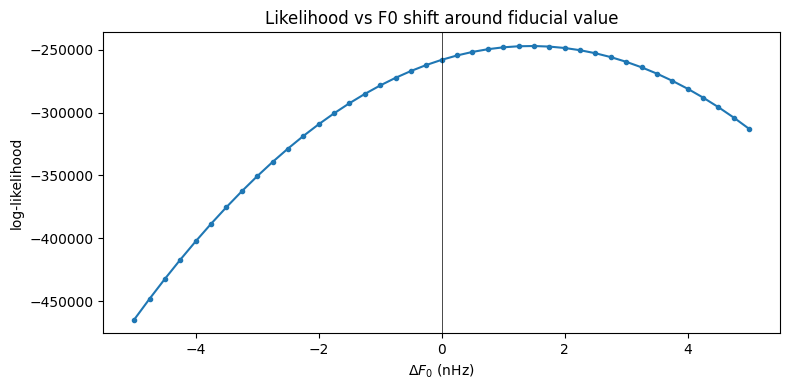

In [4]:
plt.figure(figsize=(8, 4))
plt.plot(np.array(df0_grid) * 1e9, np.array(logL_curve), ".-")
plt.xlabel(r"$\Delta F_0$ (nHz)")
plt.ylabel("log-likelihood")
plt.title("Likelihood vs F0 shift around fiducial value")
plt.axvline(0, color="k", linewidth=0.5)
plt.tight_layout()
plt.show()

## 3. Build priors and call `marginalize_single_pulsar`

The convention encoded in `marg_set_from_priors` is that
`ImproperPrior` ⇒ marginalize. Assigning an improper prior to every free
parameter is the "marg the timing params, no prior information" recipe.

We pass `allow_nonlinear=True` because `RAJ` and `DECJ` enter the residuals
through the Earth–Sun geometry and so fail the strict (1e-6) linearity
tolerance. The Laplace approximation around the fiducial point is good enough
for an illustrative example, and matches what `discovery` does in practice.

In [5]:
priors = {n: ImproperPrior() for n in params.free_names()}
over = marg_set_from_priors(priors)
print(f"over (to be marginalized): {sorted(over)}")

logL_marg, sampled_priors, reduced_skel = marginalize_single_pulsar(over=over,
    priors=priors,
    toa_data=toa_data,
    timing_model=timing_model,
    noise_model=noise_model,
    fiducial_params=params,
    allow_nonlinear=True,
)

print(f"\nmarginalized names: {reduced_skel.marginalized_names()}")
print(f"remaining free names: {reduced_skel.free_names()}")
print(f"sampled_priors keys: {list(sampled_priors)}")

over (to be marginalized): ['DECJ', 'DM', 'F0', 'F1', 'RAJ']

marginalized names: ('RAJ', 'DECJ', 'F0', 'F1', 'DM')
remaining free names: ()
sampled_priors keys: []


/tmp/ipykernel_783993/555793492.py:5: UserWarning: marginalize: marginalizing nonlinear parameter(s) via Laplace approximation around the fiducial parameters: DECJ (ratio=1.88e-06). Marginalized likelihood is accurate to O((y - y_fid)^2). For exact treatment, sample these parameters instead.
  logL_marg, sampled_priors, reduced_skel = marginalize_single_pulsar(over=over,


## 4. Demo 1 — marginalized parameters drop out

Once a parameter is in `over`, its value in the parameter vector no longer
affects the marginalized log-likelihood: the integral against the improper
prior has already been performed. We verify this by shifting `F0` by the same
5 nHz that drastically changed `single_pulsar_logL` in Section 2.

In [6]:
logL_marg_baseline = float(logL_marg(reduced_skel))
print(f"logL_marg (baseline):       {logL_marg_baseline:.6f}")

orig_f0 = float(reduced_skel.values[reduced_skel.param_index("F0")])
shifted = reduced_skel.with_value("F0", orig_f0 + 5e-9)
logL_marg_shifted = float(logL_marg(shifted))
print(f"logL_marg (F0 + 5 nHz):     {logL_marg_shifted:.6f}")
print(f"difference:                  {logL_marg_shifted - logL_marg_baseline:.3e}")

assert abs(logL_marg_shifted - logL_marg_baseline) < 1e-6, (
    "marginalized logL should be invariant under shifts of marg'd params"
)
print("\nMarginalized logL is invariant under F0 shifts, as expected.")

logL_marg (baseline):       236.483238
logL_marg (F0 + 5 nHz):     236.483238
difference:                  0.000e+00

Marginalized logL is invariant under F0 shifts, as expected.


## 5. Demo 2 — connection to the WLS / Laplace mode

For parameters that enter the residuals linearly, marginalizing against a
flat prior is mathematically the same as a Laplace integral around the
maximum-likelihood point:

$$\log Z_{\rm flat} \;\approx\; \log L(\hat y) \;+\; \tfrac{k}{2}\log(2\pi) \;+\; \tfrac{1}{2}\log|\Sigma_{\rm WLS}|$$

Inside `marginalize_single_pulsar()` the improper prior is implemented as a wide Gaussian
with variance $\Phi = 10^{40}$. That Gaussian is normalized, so what
`marginalize_single_pulsar` actually computes differs from the flat-prior integral by the
Gaussian normalization $(2\pi\Phi)^{-k/2}$, giving the closed-form
prediction

$$\texttt{logL\_marg} \;=\; \log L(\hat y) \;+\; \tfrac{1}{2}\log|\Sigma_{\rm WLS}| \;-\; \tfrac{k}{2}\log\Phi.$$

Plugging in the WLS fit, this prediction should match `logL_marg` up to a
small Laplace-approximation residual driven by the (mild) nonlinearity in
`RAJ` and `DECJ`.

In [7]:
fitter = WLSFitter(timing_model, toa_data, params, noise_model=noise_model)
_ = fitter.fit_toas(maxiter=1)        # JIT warmup
wls = fitter.fit_toas(maxiter=99)

wls_params = wls.params
wls_cov = np.array(wls.covariance_matrix)
wls_unc = np.array(wls.parameter_uncertainties)
wls_free_names = wls_params.free_names()

print(f"reduced chi^2: {wls.reduced_chi2:.4f}")
print()
print(f"{'parameter':<8} {'value':>20} {'sigma':>14}")
print("-" * 44)
for n, v, s in zip(wls_free_names, wls_params.free_values(), wls_unc):
    print(f"{n:<8} {float(v):>20.10g} {float(s):>14.4g}")

reduced chi^2: 1.0638

parameter                value          sigma
--------------------------------------------
RAJ               4.663868852      9.835e-09
DECJ            -0.3553169572      1.593e-07
F0                61.48547655      1.809e-11
F1           -1.181331692e-15      1.442e-18
DM                224.1137963        0.03494


In [8]:
logL_at_map = float(single_pulsar_logL(toa_data, timing_model, noise_model, wls_params))
k = len(wls_free_names)
phi = 1e40    # marginalize_single_pulsar() uses Phi = 1e40 as the improper-prior proxy
logdet_cov = float(np.linalg.slogdet(wls_cov)[1])
laplace_predicted = logL_at_map + 0.5 * logdet_cov - 0.5 * k * np.log(phi)

print(f"logL at fiducial:           {logL_fid:.3f}")
print(f"logL at WLS MAP:            {logL_at_map:.3f}")
print(f"0.5 * log|Sigma_WLS|:       {0.5 * logdet_cov:.3f}")
print(f"-0.5 * k * log(Phi):        {-0.5 * k * np.log(phi):.3f}")
print(f"closed-form prediction:     {laplace_predicted:.3f}")
print(f"logL_marg:                  {logL_marg_baseline:.3f}")
print(f"residual (Laplace error):   {logL_marg_baseline - laplace_predicted:+.3e}")

logL at fiducial:           -257988.879
logL at WLS MAP:            571.592
0.5 * log|Sigma_WLS|:       -103.922
-0.5 * k * log(Phi):        -230.259
closed-form prediction:     237.412
logL_marg:                  236.483
residual (Laplace error):   -9.286e-01


## 6. Demo 3 — partial marginalization: a 1-D DM profile

Marginalization does not have to be all-or-nothing. By `exclude`-ing a
parameter from the `over` set we keep it sampled. We exclude `DM` so the
marginalized likelihood becomes a function of DM alone — the other four
timing parameters are integrated out at each DM value.

The resulting 1-D profile should look like a Gaussian centred on the WLS
estimate of DM with width equal to the WLS DM uncertainty.

In [9]:
over_partial = marg_set_from_priors(priors, exclude={"DM"})
print(f"partial over set: {sorted(over_partial)}")

logL_marg_dm, sampled_dm, skel_dm = marginalize_single_pulsar(over=over_partial,
    priors=priors,
    toa_data=toa_data,
    timing_model=timing_model,
    noise_model=noise_model,
    fiducial_params=params,
    allow_nonlinear=True,
)
print(f"free names in reduced skeleton: {skel_dm.free_names()}")

partial over set: ['DECJ', 'F0', 'F1', 'RAJ']
free names in reduced skeleton: ('DM',)


/tmp/ipykernel_783993/358703373.py:4: UserWarning: marginalize: marginalizing nonlinear parameter(s) via Laplace approximation around the fiducial parameters: DECJ (ratio=1.88e-06). Marginalized likelihood is accurate to O((y - y_fid)^2). For exact treatment, sample these parameters instead.
  logL_marg_dm, sampled_dm, skel_dm = marginalize_single_pulsar(over=over_partial,


In [10]:
dm_map = float(wls_params.free_values()[wls_free_names.index("DM")])
dm_sigma = float(wls_unc[wls_free_names.index("DM")])

dm_grid = jnp.linspace(dm_map - 5 * dm_sigma, dm_map + 5 * dm_sigma, 60)

@jax.jit
def profile(dm):
    skel = skel_dm.with_free_values(jnp.array([dm]))
    return logL_marg_dm(skel)

profile_curve = jax.vmap(profile)(dm_grid)
profile_np = np.array(profile_curve)
dm_grid_np = np.array(dm_grid)

argmax_dm = float(dm_grid_np[np.argmax(profile_np)])
print(f"WLS DM:           {dm_map:.6f}")
print(f"profile peak DM:  {argmax_dm:.6f}")
print(f"WLS DM sigma:     {dm_sigma:.6f}")
assert abs(argmax_dm - dm_map) < 0.5 * dm_sigma, (
    "marginalized DM profile peak should sit near the WLS DM estimate"
)

WLS DM:           224.113796
profile peak DM:  224.116757
WLS DM sigma:     0.034939


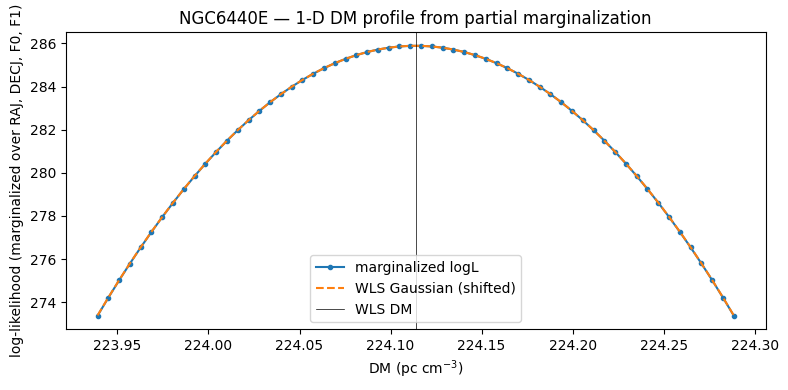

In [11]:
# Overlay the Gaussian implied by the WLS uncertainty for comparison
gauss = -0.5 * ((dm_grid_np - dm_map) / dm_sigma) ** 2
gauss_shift = profile_np.max() - gauss.max()

plt.figure(figsize=(8, 4))
plt.plot(dm_grid_np, profile_np, ".-", label="marginalized logL")
plt.plot(dm_grid_np, gauss + gauss_shift, "--", label="WLS Gaussian (shifted)")
plt.axvline(dm_map, color="k", linewidth=0.5, label="WLS DM")
plt.xlabel("DM (pc cm$^{-3}$)")
plt.ylabel("log-likelihood (marginalized over RAJ, DECJ, F0, F1)")
plt.title("NGC6440E — 1-D DM profile from partial marginalization")
plt.legend()
plt.tight_layout()
plt.show()